# Experiment 02: Model Tuning (XGBoost)

## Цель эксперимента
1. Сравнить XGBoost с baseline Logistic Regression
2. Подобрать оптимальные гиперпараметры для XGBoost
3. Выбрать лучшую модель для production

## Используемые данные
- Датасет: Churn_Modelling.csv (10,000 клиентов)
- Признаки: 13 (после feature engineering)
- Целевая переменная: Exited (отток)
## План эксперимента
1. Загрузка и предобработка данных (через DataPreprocessor)
2. Baseline: Logistic Regression
3. XGBoost с настройкой гиперпараметров (GridSearchCV)
4. Сравнение моделей по метрикам
5. Сохранение лучшей модели

## Ожидаемые результаты
- Baseline ROC-AUC: ~0.85
- XGBoost ROC-AUC: >0.87

In [2]:
# Импорт библиотек
import sys
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import joblib
from datetime import datetime

# Настройки
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

# Добавляем путь к src
sys.path.append('..')
sys.path.append(os.path.abspath('..'))

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

# Импортируем наш препроцессор
from src.data.preprocess import DataPreprocessor

print("Библиотеки загружены")
print(f"Версия XGBoost: {xgb.__version__}")

Библиотеки загружены
Версия XGBoost: 3.2.0


In [3]:
# Загрузка конфигурации
config_path = "../configs/config.yaml"
if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    print("Конфигурация загружена из config.yaml")
else:
    config = {
        'random_state': 42,
        'test_size': 0.2
    }
    print("Используется конфигурация по умолчанию")

RANDOM_STATE = config.get('random_state', 42)
TEST_SIZE = config.get('test_size', 0.2)

print(f"Random state: {RANDOM_STATE}")
print(f"Test size: {TEST_SIZE}")

Конфигурация загружена из config.yaml
Random state: 42
Test size: 0.2


In [43]:
# Загрузка и предобработка данных

# Загружаем сырые данные
df_raw = pd.read_csv('../data/raw/Churn_Modelling.csv')
print(f"Загружено {len(df_raw)} записей")
print(f"Исходные колонки: {list(df_raw.columns)}")

# Инициализируем препроцессор
preprocessor = DataPreprocessor()

# Обрабатываем данные (fit_scaler=True для обучения)
X_scaled, y, df_processed = preprocessor.preprocess(df_raw, fit_scaler=True)

# Сохраняем препроцессор для сервиса
os.makedirs('../artifacts', exist_ok=True)
preprocessor.save('../artifacts/preprocessor.pkl')
print("Препроцессор сохранён в artifacts/preprocessor.pkl")

print(f"\nПосле предобработки:")
print(f"  - Признаков: {X_scaled.shape[1]}")
print(f"  - Целевая переменная: {y.name}")
print(f"  - Распределение: {y.value_counts().to_dict()}")

INFO:src.data.preprocess:DataPreprocessor инициализирован
INFO:src.data.preprocess:Создано 21 признаков
INFO:src.data.preprocess:Данные очищены. Форма: (10000, 14)
INFO:src.data.preprocess:Scaler обучен и применён
INFO:src.data.preprocess:Препроцессор сохранён в ../artifacts/preprocessor.pkl


Загружено 10000 записей
Исходные колонки: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
Препроцессор сохранён в artifacts/preprocessor.pkl

После предобработки:
  - Признаков: 13
  - Целевая переменная: Exited
  - Распределение: {0: 7963, 1: 2037}


In [44]:
# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"\nРазделение данных:")
print(f"  - Train: {X_train.shape[0]} записей (отток: {y_train.mean():.2%})")
print(f"  - Test: {X_test.shape[0]} записей (отток: {y_test.mean():.2%})")


Разделение данных:
  - Train: 8000 записей (отток: 20.38%)
  - Test: 2000 записей (отток: 20.35%)


In [51]:
# Сохраняем обработанные данные для отладки (опционально)
df_processed.to_csv('../data/sample/processed_sample.csv', index=False)
print("Обработанные данные сохранены в data/sample/processed_sample.csv")

Обработанные данные сохранены в data/sample/processed_sample.csv


In [52]:
# Baseline Model: Logistic Regression

# Загружаем baseline модель, сохранённую в 01 ноутбуке
baseline_path = '../artifacts/models/logreg_baseline_v1.pkl'

if os.path.exists(baseline_path):
    lr = joblib.load(baseline_path)
    print("Baseline модель загружена из", baseline_path)
else:
    print(f"Ошибка: Файл {baseline_path} не найден!")
    print("Сначала выполните ноутбук 01_eda_and_baseline.ipynb для сохранения модели")
    raise FileNotFoundError(f"Baseline модель не найдена: {baseline_path}")
    
# Предсказания
y_pred_lr = lr.predict(X_test)
y_pred_proba_lr = lr.predict_proba(X_test)[:, 1]

# Метрики
print(f"\nМетрики на тестовой выборке:")
print(f"  - Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"  - Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"  - Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"  - F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"  - ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

Baseline модель загружена из ../artifacts/models/logreg_baseline_v1.pkl

Метрики на тестовой выборке:
  - Accuracy:  0.8530
  - Precision: 0.7557
  - Recall:    0.4103
  - F1-Score:  0.5318
  - ROC-AUC:   0.8444


In [54]:
# XGBoost Model (Default)

# Базовый XGBoost
xgb_default = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_default.fit(X_train, y_train)

# Предсказания
y_pred_xgb = xgb_default.predict(X_test)
y_pred_proba_xgb = xgb_default.predict_proba(X_test)[:, 1]

# Метрики
print(f"\nМетрики на тестовой выборке:")
print(f"  - Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"  - Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"  - Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"  - F1-Score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"  - ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")


Метрики на тестовой выборке:
  - Accuracy:  0.8540
  - Precision: 0.7291
  - Recall:    0.4496
  - F1-Score:  0.5562
  - ROC-AUC:   0.8539


In [55]:
# XGBoost Hyperparameter Tuning

# Параметры для поиска
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.001, 0.05, 0.01],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

print("Параметры для поиска:")
for param, values in param_grid.items():
    print(f"  - {param}: {values}")

# Grid Search
xgb_model = xgb.XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    use_label_encoder=False
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    xgb_model,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("\nЗапуск Grid Search...")
grid_search.fit(X_train, y_train)

print(f"\nЛучшие параметры:")
for param, value in grid_search.best_params_.items():
    print(f"  - {param}: {value}")
print(f"\nЛучший CV ROC-AUC: {grid_search.best_score_:.4f}")


Параметры для поиска:
  - n_estimators: [100, 200, 300]
  - max_depth: [3, 5, 7]
  - learning_rate: [0.001, 0.05, 0.01]
  - subsample: [0.8, 1.0]
  - colsample_bytree: [0.8, 1.0]

Запуск Grid Search...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Лучшие параметры:
  - colsample_bytree: 0.8
  - learning_rate: 0.05
  - max_depth: 3
  - n_estimators: 200
  - subsample: 0.8

Лучший CV ROC-AUC: 0.8501


In [56]:
# Финальная XGBoost модель
best_xgb = grid_search.best_estimator_

# Предсказания
y_pred_best = best_xgb.predict(X_test)
y_pred_proba_best = best_xgb.predict_proba(X_test)[:, 1]

# Метрики
print("\nМетрики оптимизированной модели:")
print(f"  - Accuracy:  {accuracy_score(y_test, y_pred_best):.4f}")
print(f"  - Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"  - Recall:    {recall_score(y_test, y_pred_best):.4f}")
print(f"  - F1-Score:  {f1_score(y_test, y_pred_best):.4f}")
print(f"  - ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_best):.4f}")


Метрики оптимизированной модели:
  - Accuracy:  0.8585
  - Precision: 0.7650
  - Recall:    0.4398
  - F1-Score:  0.5585
  - ROC-AUC:   0.8590


In [57]:
# Сравнение моделей
# Сбор метрик
results = pd.DataFrame({
    'Model': ['Logistic Regression (Baseline)', 'XGBoost (Default)', 'XGBoost (Optimized)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_best)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_best)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_best)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_best)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_proba_lr),
        roc_auc_score(y_test, y_pred_proba_xgb),
        roc_auc_score(y_test, y_pred_proba_best)
    ]
})

print(results.round(4).to_string(index=False))

# Сохраняем результаты
results.to_csv('../artifacts/model_comparison.csv', index=False)
print("\nРезультаты сохранены в artifacts/model_comparison.csv")

                         Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression (Baseline)    0.8530     0.7557  0.4103    0.5318   0.8444
             XGBoost (Default)    0.8540     0.7291  0.4496    0.5562   0.8539
           XGBoost (Optimized)    0.8585     0.7650  0.4398    0.5585   0.8590

Результаты сохранены в artifacts/model_comparison.csv


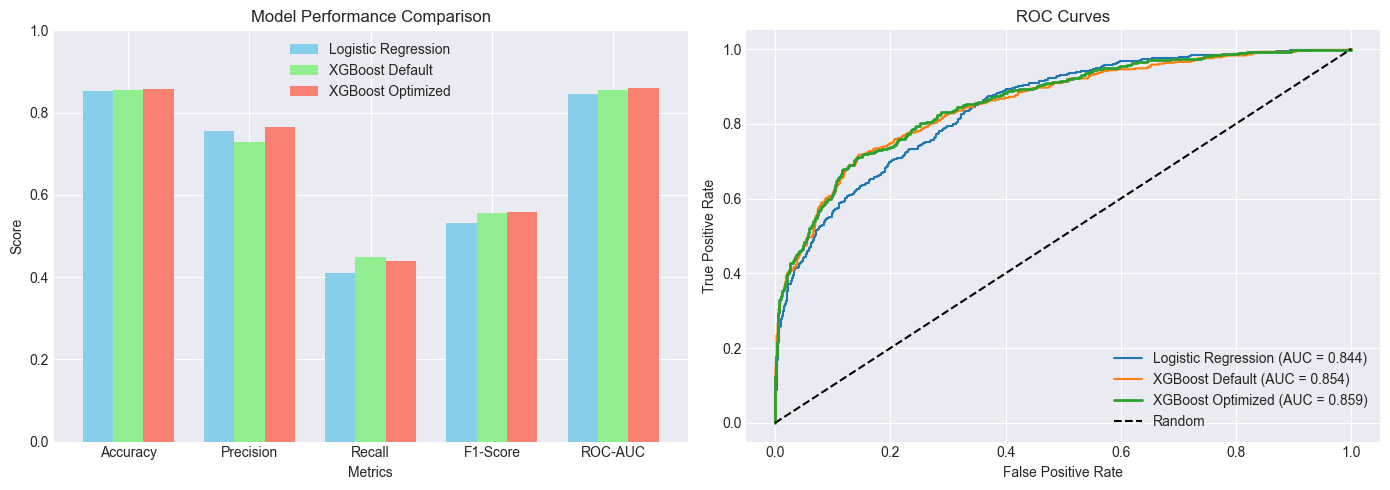

In [58]:
# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot сравнения
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

axes[0].bar(x - width, results.iloc[0][metrics], width, label='Logistic Regression', color='skyblue')
axes[0].bar(x, results.iloc[1][metrics], width, label='XGBoost Default', color='lightgreen')
axes[0].bar(x + width, results.iloc[2][metrics], width, label='XGBoost Optimized', color='salmon')
axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x, metrics)
axes[0].legend()
axes[0].set_ylim(0, 1)

# ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
fpr_best, tpr_best, _ = roc_curve(y_test, y_pred_proba_best)

axes[1].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {results.iloc[0]["ROC-AUC"]:.3f})')
axes[1].plot(fpr_xgb, tpr_xgb, label=f'XGBoost Default (AUC = {results.iloc[1]["ROC-AUC"]:.3f})')
axes[1].plot(fpr_best, tpr_best, label=f'XGBoost Optimized (AUC = {results.iloc[2]["ROC-AUC"]:.3f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('../artifacts/model_comparison_plot.png', dpi=150)
plt.show()



Classification Report:
              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92      1593
     Churned       0.76      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000



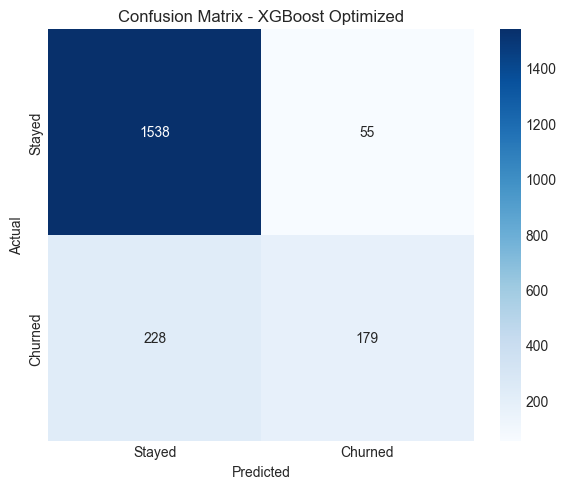


5-Fold Cross-Validation ROC-AUC: 0.8537 (+/- 0.0048)
  - Scores: [0.86046193 0.85264019 0.85274334 0.85669491 0.84608491]


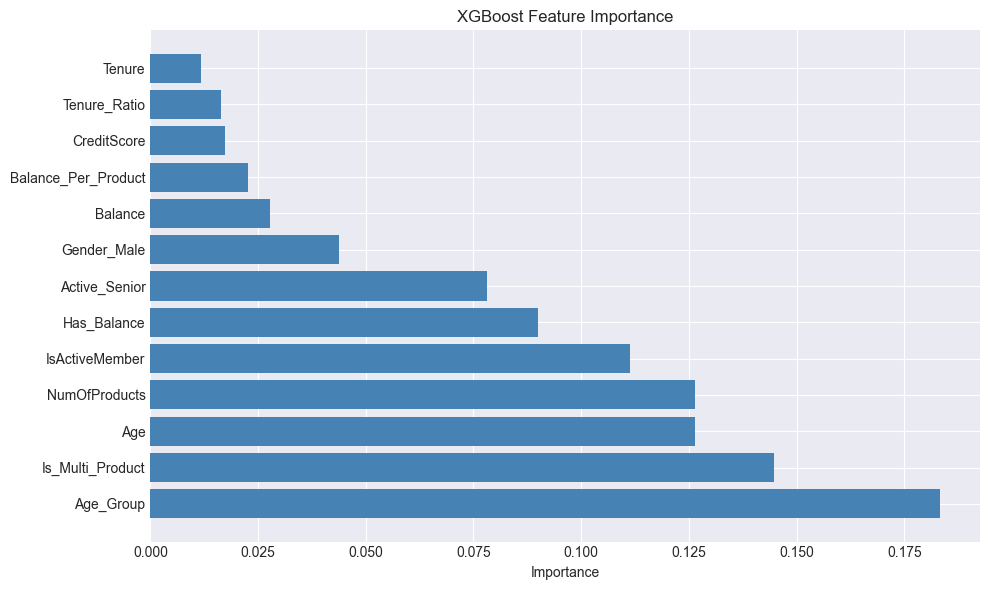


Топ-5 важнейших признаков:
  - Age_Group: 0.1834
  - Is_Multi_Product: 0.1447
  - Age: 0.1265
  - NumOfProducts: 0.1264
  - IsActiveMember: 0.1113


In [60]:
# Детальный анализ лучшей модели (XGBoost Optimized)
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Stayed', 'Churned']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Confusion Matrix - XGBoost Optimized')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../artifacts/xgb_confusion_matrix.png', dpi=150)
plt.show()

# Cross-validation score
cv_scores = cross_val_score(best_xgb, X_scaled, y, cv=5, scoring='roc_auc')
print(f"\n5-Fold Cross-Validation ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"  - Scores: {cv_scores}")

# Feature Importance (XGBoost)
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.savefig('../artifacts/xgb_feature_importance.png', dpi=150)
plt.show()

print("\nТоп-5 важнейших признаков:")
for i, row in importance_df.head(5).iterrows():
    print(f"  - {row['Feature']}: {row['Importance']:.4f}")

Оптимальный порог по F1-score: 0.2819
  - Precision при этом пороге: 0.5961
  - Recall при этом пороге: 0.6781
  - F1-score: 0.6345

Метрики при оптимальном пороге:
  - Accuracy:  0.8410
  - Precision: 0.5961
  - Recall:    0.6781
  - F1-Score:  0.6345


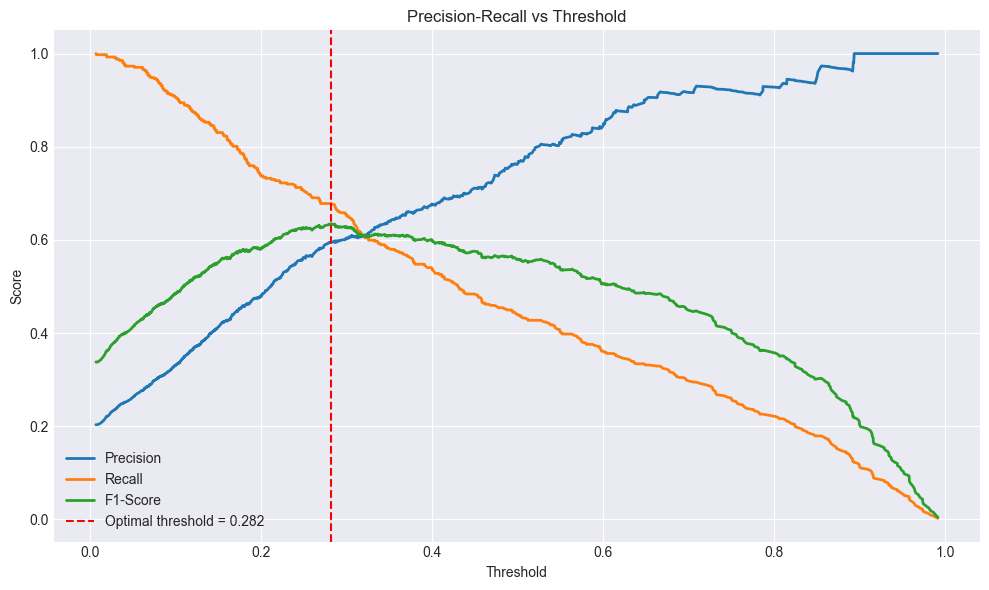

In [61]:
# Оптимизация порога классификации
# Precision-Recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba_best)

# Находим оптимальный порог по F1-score
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5

print(f"Оптимальный порог по F1-score: {optimal_threshold:.4f}")
print(f"  - Precision при этом пороге: {precisions[optimal_idx]:.4f}")
print(f"  - Recall при этом пороге: {recalls[optimal_idx]:.4f}")
print(f"  - F1-score: {f1_scores[optimal_idx]:.4f}")

# Сравнение с порогом 0.5
y_pred_optimized = (y_pred_proba_best >= optimal_threshold).astype(int)
print(f"\nМетрики при оптимальном пороге:")
print(f"  - Accuracy:  {accuracy_score(y_test, y_pred_optimized):.4f}")
print(f"  - Precision: {precision_score(y_test, y_pred_optimized):.4f}")
print(f"  - Recall:    {recall_score(y_test, y_pred_optimized):.4f}")
print(f"  - F1-Score:  {f1_score(y_test, y_pred_optimized):.4f}")

# Визуализация поиска порога
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision', linewidth=2)
plt.plot(thresholds, recalls[:-1], label='Recall', linewidth=2)
plt.plot(thresholds, f1_scores[:-1], label='F1-Score', linewidth=2)
plt.axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Optimal threshold = {optimal_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.tight_layout()
plt.savefig('../artifacts/threshold_optimization.png', dpi=150)
plt.show()

In [62]:
# Сохранение финальной модели

# Сохраняем лучшую модель
joblib.dump(best_xgb, '../artifacts/models/xgb_final_v1.pkl')
print("Модель сохранена в artifacts/models/xgb_final_v1.pkl")

# Сохраняем оптимальный порог
threshold_config = {'optimal_threshold': float(optimal_threshold)}
with open('../artifacts/threshold_config.yaml', 'w') as f:
    yaml.dump(threshold_config, f)
print("Порог сохранён в artifacts/threshold_config.yaml")

# Сохраняем метаданные эксперимента
experiment_metadata = {
    'experiment_date': datetime.now().isoformat(),
    'model_type': 'XGBoost',
    'best_params': grid_search.best_params_,
    'optimal_threshold': float(optimal_threshold),
    'test_roc_auc': float(roc_auc_score(y_test, y_pred_proba_best)),
    'test_f1': float(f1_score(y_test, y_pred_best)),
    'cv_mean': float(cv_scores.mean()),
    'cv_std': float(cv_scores.std()),
    'features': feature_names,
    'feature_importance': importance_df.to_dict('records')
}

with open('../artifacts/experiment_metadata.yaml', 'w') as f:
    yaml.dump(experiment_metadata, f, default_flow_style=False)
print("Метаданные эксперимента сохранены в artifacts/experiment_metadata.yaml")

Модель сохранена в artifacts/models/xgb_final_v1.pkl
Порог сохранён в artifacts/threshold_config.yaml
Метаданные эксперимента сохранены в artifacts/experiment_metadata.yaml


**Результаты эксперимента:**

1. **Baseline (Logistic Regression)**
   - ROC-AUC: {:.4f}
   - Хороший baseline, но есть потенциал для улучшения

2. **XGBoost (Optimized)**
   - ROC-AUC: {:.4f} (улучшение на {:.1%})
   - Лучшие параметры: {}
   - Оптимальный порог: {:.3f}

3. **Ключевые признаки оттока:**
   - Возраст (Age)
   - Количество продуктов (NumOfProducts)
   - Баланс на продукт (Balance_Per_Product)
   - Активность клиента (IsActiveMember)

4. **Рекомендации для бизнеса:**
   - Клиенты старше 50 лет требуют особого внимания
   - Клиенты с 3+ продуктами — группа высокого риска
   - Активные клиенты лояльнее, их нужно поощрять

**Финальное решение:**
Выбрана XGBoost модель для production с порогом {:.3f}
""".format(
    results.iloc[0]['ROC-AUC'],
    results.iloc[2]['ROC-AUC'],
    (results.iloc[2]['ROC-AUC'] - results.iloc[0]['ROC-AUC']),
    grid_search.best_params_,
    optimal_threshold)

Сохранённые артефакты:
  - artifacts/models/logreg_baseline_v1.pkl
  - artifacts/models/xgb_final_v1.pkl
  - artifacts/preprocessor.pkl
  - artifacts/model_comparison.csv
  - artifacts/threshold_config.yaml
  - artifacts/experiment_metadata.yaml

Все артефакты готовы для использования в сервисе!